# STA365 Homework 8

### Question 1

For this question, I will be using the accident.csv dataset from: https://www.kaggle.com/datasets/himelsarder/road-accident-survival-dataset.

In [2]:
import pandas
accident_data = pandas.read_csv('accident.csv')
accident_data

,Age,Gender,Speed_of_Impact,Helmet_Used,Seatbelt_Used,Survived
0,56,Female,27.0,No,No,1
1,69,Female,46.0,No,Yes,1
2,46,Male,46.0,Yes,Yes,0
3,32,Male,117.0,No,Yes,0
4,60,Female,40.0,Yes,Yes,0
...,...,...,...,...,...,...
195,69,Female,111.0,No,Yes,1
196,30,Female,51.0,No,Yes,1
197,58,Male,110.0,No,Yes,1
198,20,Male,103.0,No,Yes,1


In [3]:
import pymc as pm
import numpy as np
import arviz as az
import matplotlib.pyplot as plt

# remove observations with NAs
accident_data = accident_data.dropna()

# changing categorical variables to binary
accident_data['Gender'] = accident_data['Gender'].replace({'Male': 0, 'Female': 1})
accident_data['Helmet_Used'] = accident_data['Helmet_Used'].replace({'No': 0, 'Yes': 1})
accident_data['Seatbelt_Used'] = accident_data['Seatbelt_Used'].replace({'No': 0, 'Yes': 1})
# convert binary variable data types to integers
accident_data['Gender'] = accident_data['Gender'].astype('int64')
accident_data['Helmet_Used'] = accident_data['Helmet_Used'].astype('int64')
accident_data['Seatbelt_Used'] = accident_data['Seatbelt_Used'].astype('int64')

#print(accident_data.dtypes)

/tmp/ipykernel_52/356635530.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  accident_data['Gender'] = accident_data['Gender'].replace({'Male': 0, 'Female': 1})
/tmp/ipykernel_52/356635530.py:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  accident_data['Helmet_Used'] = accident_data['Helmet_Used'].replace({'No': 0, 'Yes': 1})
/tmp/ipykernel_52/356635530.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value in

In [3]:
# standardizing the continuous predictors to prevent divergences, can transform back after if needed for interp
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
accident_data[['Age', 'Speed_of_Impact']] = scaler.fit_transform(accident_data[['Age', 'Speed_of_Impact']])

# extract variables
age = accident_data['Age'].values
gender = accident_data['Gender'].values
speed = accident_data['Speed_of_Impact'].values
helmet = accident_data['Helmet_Used'].values
seatbelt = accident_data['Seatbelt_Used'].values
survived = accident_data['Survived'].values

# create design matrix X_(nxp)
X = np.column_stack([age, gender, speed, helmet, seatbelt])
p = X.shape[1]  # p = 5 predictors
np.random.seed(365)



with pm.Model() as logistic_model:
    # prior for the intercept
    intercept = pm.Normal('intercept', mu=0, sigma=10)
    
    # vectorized prior for beta coefficients
    betas = pm.Normal('betas', mu=0, sigma=10, shape=p)
    
    # logit link function
    logit = intercept + pm.math.dot(X, betas)
    
    # likelihood: modeling the outcome as a Bernoulli rv
    likelihood = pm.Bernoulli('likelihood', logit_p=logit, observed=survived)
    
    # sample
    trace = pm.sample(draws=3000, tune=1000, target_accept=0.95, chains=4, random_seed=365)

/tmp/ipykernel_53/2263908278.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  accident_data[['Age', 'Speed_of_Impact']] = scaler.fit_transform(accident_data[['Age', 'Speed_of_Impact']])
Auto-assigning NUTS sampler...
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [intercept, betas]


Sampling 4 chains for 1_000 tune and 3_000 draw iterations (4_000 + 12_000 draws total) took 8 seconds.


In [4]:
az.summary(trace, round_to=5)

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
betas[0],0.28300,0.15356,-0.00996,0.56771,0.00135,0.00108,12960.91403,7988.96977,1.00100
betas[1],-0.54739,0.30035,-1.12741,-0.00482,0.00276,0.00208,11831.01960,8884.73412,1.00013
betas[2],0.07303,0.14911,-0.19823,0.36390,0.00125,0.00130,14193.33412,8445.06258,1.00014
betas[3],-0.33029,0.30161,-0.88900,0.23412,0.00263,0.00221,13169.88476,9069.61475,1.00040
betas[4],0.32928,0.30030,-0.21401,0.90924,0.00267,0.00223,12612.80788,8529.48421,1.00003
intercept,0.34855,0.31325,-0.24047,0.94076,0.00313,0.00238,10040.92172,8502.78256,1.00021


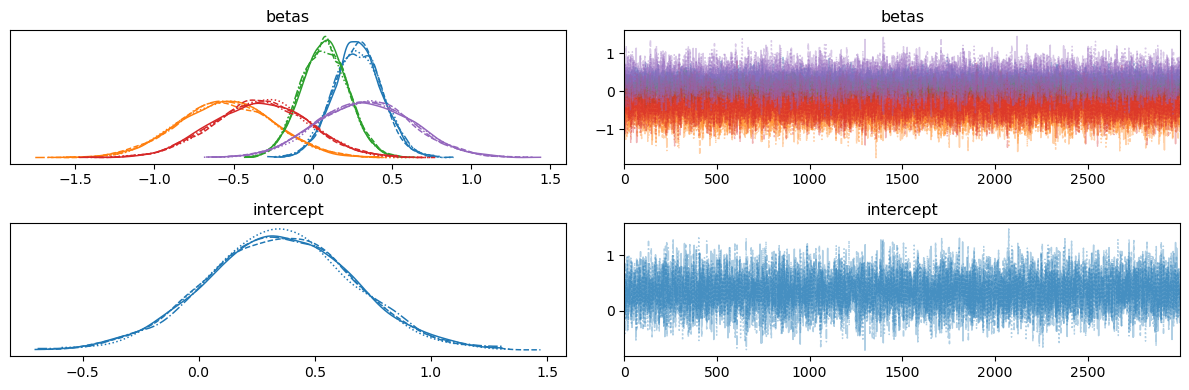

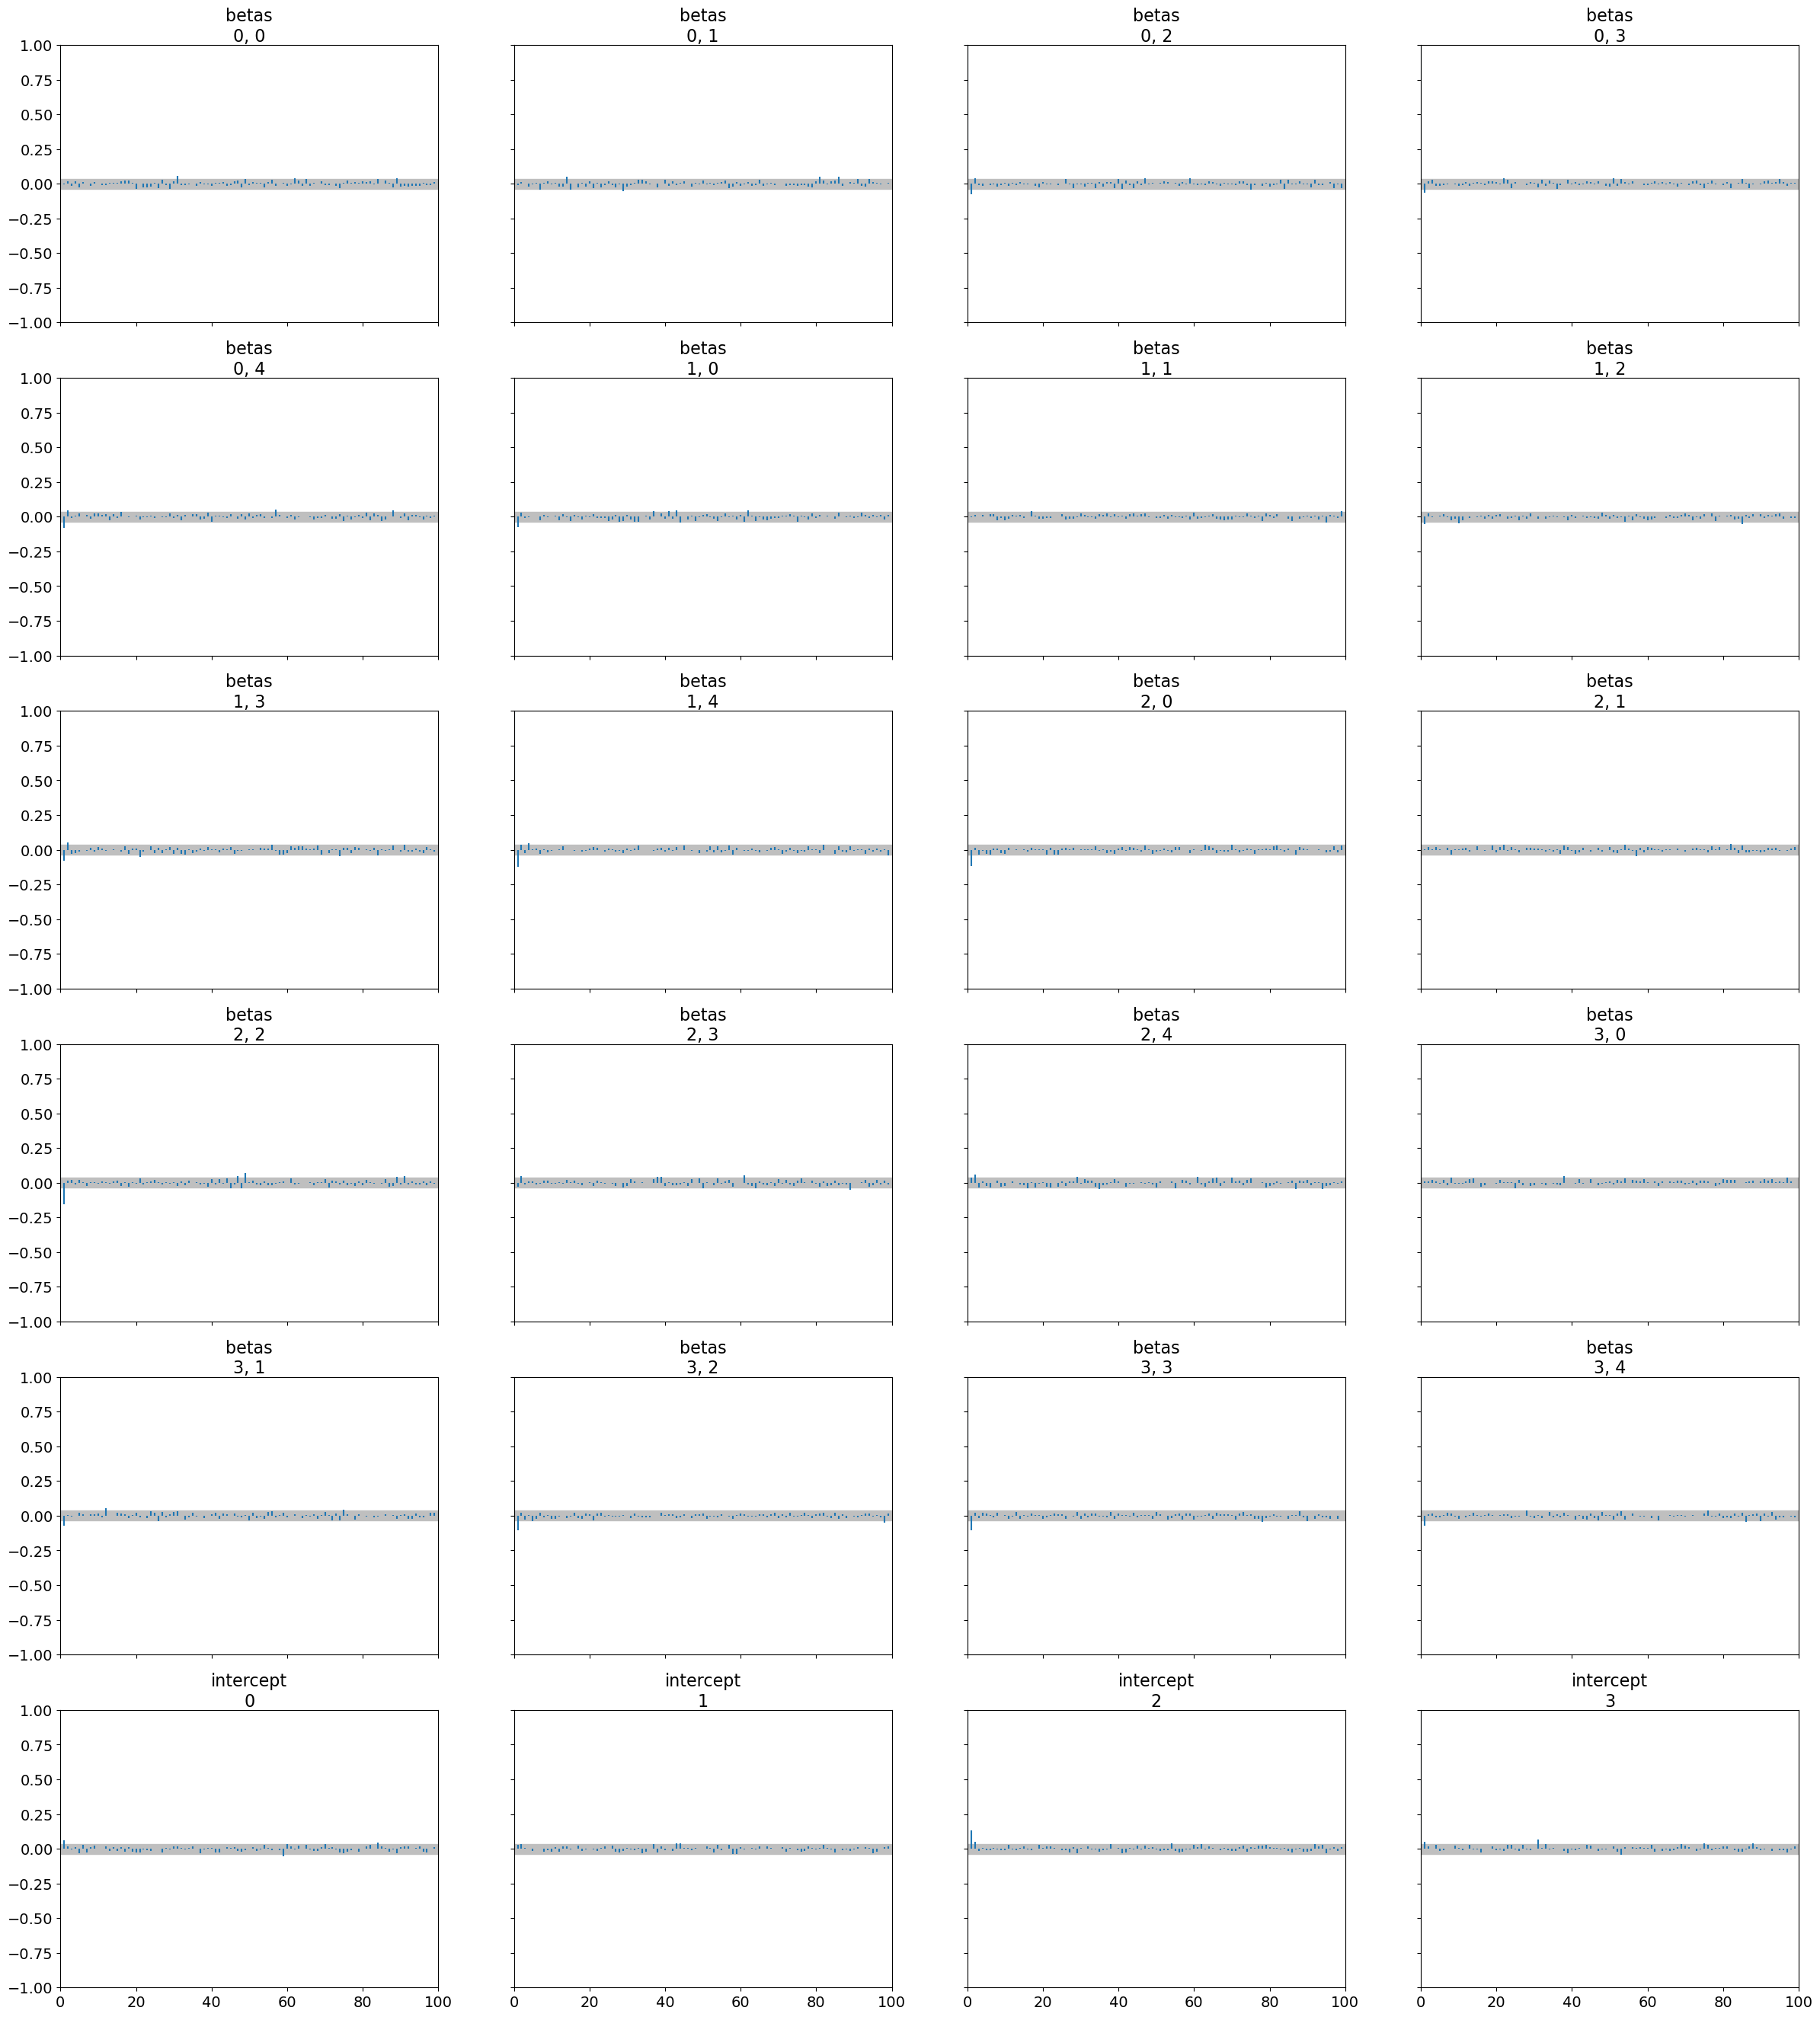

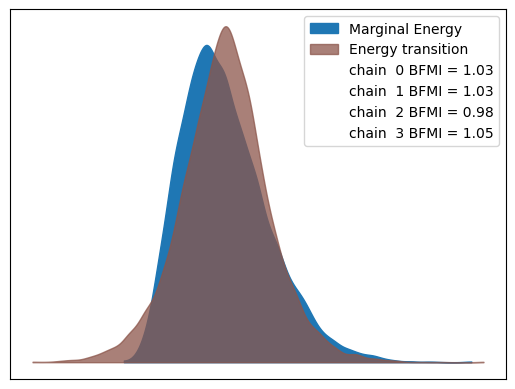

In [9]:
az.plot_trace(trace)
plt.tight_layout()
plt.show()

az.plot_autocorr(trace)
plt.show()

az.plot_energy(trace)
plt.show()

#### Inference with Bayesian posterior analysis and MCMC diagnostics

* The r_hat statistic for the intercept and all five regression coefficients are less than 1.01 and are very close to 1, indicating the chains are mixing well and converging on the same results.
* From the trace plots above, we see that the chains are in agreement and have converged closely on the same result for each parameter.
* In this example, we took a total of 12,000 draws for each parameter. ess_bulk is approximately 12,961 for betas[0], 11,831 for betas[1], 14,193 for betas[2], 13,170 for betas[3], 12,613 for betas[4], and 10,041 for the intercept, meaning we have taken the rough equivalent of this many independent samples for each respective parameter. Having the rough equivalent of this many samples for each parameter seems sufficient, as our other diagnostics explained in the previous points suggest the chains have converged and have mixed well. In addition, the autocorrelation plots above show a near-zero autocorrelation at all lags, meaning that each sample in the chain is roughly independent of the previous samples.
* Looking at the 94% HDIs, we see that the 94% HDI for betas[1] is [-1.12741, -0.00482]. This suggests that, holding the other variables constant, the odds of survival for females is between 32.4% and 99.5% times the odds of survival for males (since exp(−1.12741) = 0.324 and exp(−0.00482) = 0.995), suggesting the true odds of survival could be lower for females compared to males. The 94% HDIs for the other betas all include 0, indicating that the data does not provide strong evidence of a positive or negative effect for these variables on survival.
* From the energy plot above, we see that the marginal energy distribution and the transition energy distribution for the most part overlap, indicating our sampler is exploring the parameter space well. In addition, we see that the BFMI for each chain is close to 1, indicating the sampler is exploring the posterior thoroughly, and that we can be confident in the estimates given by our analysis.

Overall, our analysis shows that this algorithm provided a reliable estimate of the relationship between age, gender, speed of impact, helmet_used, seatbelt_used and survival using Bayesian logistic regression.

### Question 2

For this question, I will be using the possum.csv dataset from: https://www.kaggle.com/datasets/abrambeyer/openintro-possum/data.

In [19]:
import pandas as pd
import numpy as np
import pymc as pm
from scipy import stats
import arviz as az
import matplotlib.pyplot as plt

df = pd.read_csv('possum.csv')
df = df.dropna()
df

,case,site,Pop,sex,age,hdlngth,skullw,totlngth,taill,footlgth,earconch,eye,chest,belly
0,1,1,Vic,m,8.0,94.1,60.4,89.0,36.0,74.5,54.5,15.2,28.0,36.0
1,2,1,Vic,f,6.0,92.5,57.6,91.5,36.5,72.5,51.2,16.0,28.5,33.0
2,3,1,Vic,f,6.0,94.0,60.0,95.5,39.0,75.4,51.9,15.5,30.0,34.0
3,4,1,Vic,f,6.0,93.2,57.1,92.0,38.0,76.1,52.2,15.2,28.0,34.0
4,5,1,Vic,f,2.0,91.5,56.3,85.5,36.0,71.0,53.2,15.1,28.5,33.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99,100,7,other,m,1.0,89.5,56.0,81.5,36.5,66.0,46.8,14.8,23.0,27.0
100,101,7,other,m,1.0,88.6,54.7,82.5,39.0,64.4,48.0,14.0,25.0,33.0
101,102,7,other,f,6.0,92.4,55.0,89.0,38.0,63.5,45.4,13.0,25.0,30.0
102,103,7,other,m,4.0,91.5,55.2,82.5,36.5,62.9,45.9,15.4,25.0,29.0


I will try to predict 'site', 'sex', and 'age' (p=3) using 'hdlngth', 'skullw', 'totlngth', 'taill', 'footlgth', 'chest', and 'belly' (m=7).

To save computation time, we can also reduce n (the number of observations), m (the number of outcomes), or p (the number of predictors). Since we only have 101 observations after dropping NA values, and we are using only 3 predictors, I will reduce the amount of outcomes (m) to 3, and only use 'hdlngth', 'totlngth', and 'taill' as outcomes.

In [16]:
df['sex'] = df['sex'].replace({'m': 0, 'f': 1})
df['sex'] = df['sex'].astype('int64')

site_dummies = pd.get_dummies(df['site'], prefix='site', drop_first=True)
predictors = pd.concat([site_dummies, df[['sex', 'age']]], axis=1)

X = predictors.values.astype(np.float64)

outcome_cols = ['hdlngth', 'totlngth', 'taill']

y = df[outcome_cols].values.astype(np.float64)

n, p = X.shape
m = y.shape[1]

with pm.Model() as multivariate_model:

    packed_L = pm.LKJCholeskyCov("packed_L", n=m, eta=2.0, 
                                 sd_dist=pm.Exponential.dist(1.0, shape=m), 
                                 compute_corr=False)
    L = pm.expand_packed_triangular(m, packed_L)
    
    # prior for regression coefficients
    betas = pm.Normal('betas', mu=0, sigma=1, shape=(p, m))
    
    Sigma = pm.Deterministic('Sigma', L.dot(L.T))
    
    mu = pm.math.dot(X, betas)
    
    # multivariate normal likelihood
    y_obs = pm.MvNormal('y_obs', mu=mu, chol=L, observed=y)
    
    # sample from posterior
    trace = pm.sample(draws=3000, tune=1000, target_accept=0.9, random_seed=365)

Auto-assigning NUTS sampler...
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [packed_L, betas]


/opt/conda/lib/python3.11/site-packages/pytensor/compile/function/types.py:970: RuntimeWarning: invalid value encountered in accumulate
  self.vm()
Sampling 4 chains for 1_000 tune and 3_000 draw iterations (4_000 + 12_000 draws total) took 1599 seconds.


In [17]:
az.summary(trace, round_to=5)

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
"Sigma[0, 0]",2419.90616,247.03636,1944.67391,2865.37434,3.35709,2.50393,5404.51054,6350.34647,1.00051
"Sigma[0, 1]",2287.09396,233.15162,1847.73491,2720.59511,3.19652,2.38660,5304.42348,6327.03261,1.00052
"Sigma[0, 2]",936.55010,95.82594,757.10323,1116.16427,1.31239,0.97795,5308.13999,6291.66506,1.00048
"Sigma[1, 0]",2287.09396,233.15162,1847.73491,2720.59511,3.19652,2.38660,5304.42348,6327.03261,1.00052
"Sigma[1, 1]",2170.35714,221.86044,1738.75348,2572.69356,3.05398,2.26726,5267.37430,6398.55612,1.00051
"Sigma[1, 2]",889.01036,91.20028,712.10585,1054.00342,1.25346,0.93071,5265.32950,6266.79081,1.00047
"Sigma[2, 0]",936.55010,95.82594,757.10323,1116.16427,1.31239,0.97795,5308.13999,6291.66506,1.00048
"Sigma[2, 1]",889.01036,91.20028,712.10585,1054.00342,1.25346,0.93071,5265.32950,6266.79081,1.00047
"Sigma[2, 2]",365.79442,37.89043,295.93470,438.07467,0.51688,0.38134,5329.35695,6218.36411,1.00042
"betas[0, 0]",1.38468,0.82576,-0.19452,2.90451,0.00762,0.00733,11749.69049,8747.68570,1.00020


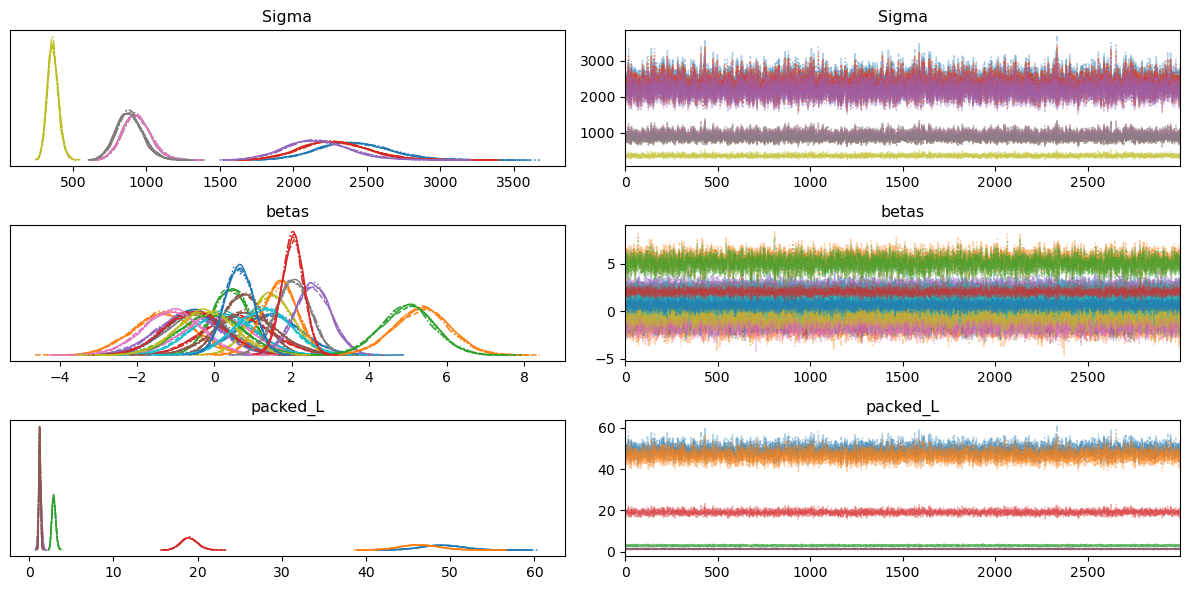

/opt/conda/lib/python3.11/site-packages/arviz/plots/plot_utils.py:270: UserWarning: rcParams['plot.max_subplots'] (40) is smaller than the number of variables to plot (156) in plot_autocorr, generating only 40 plots
  warnings.warn(


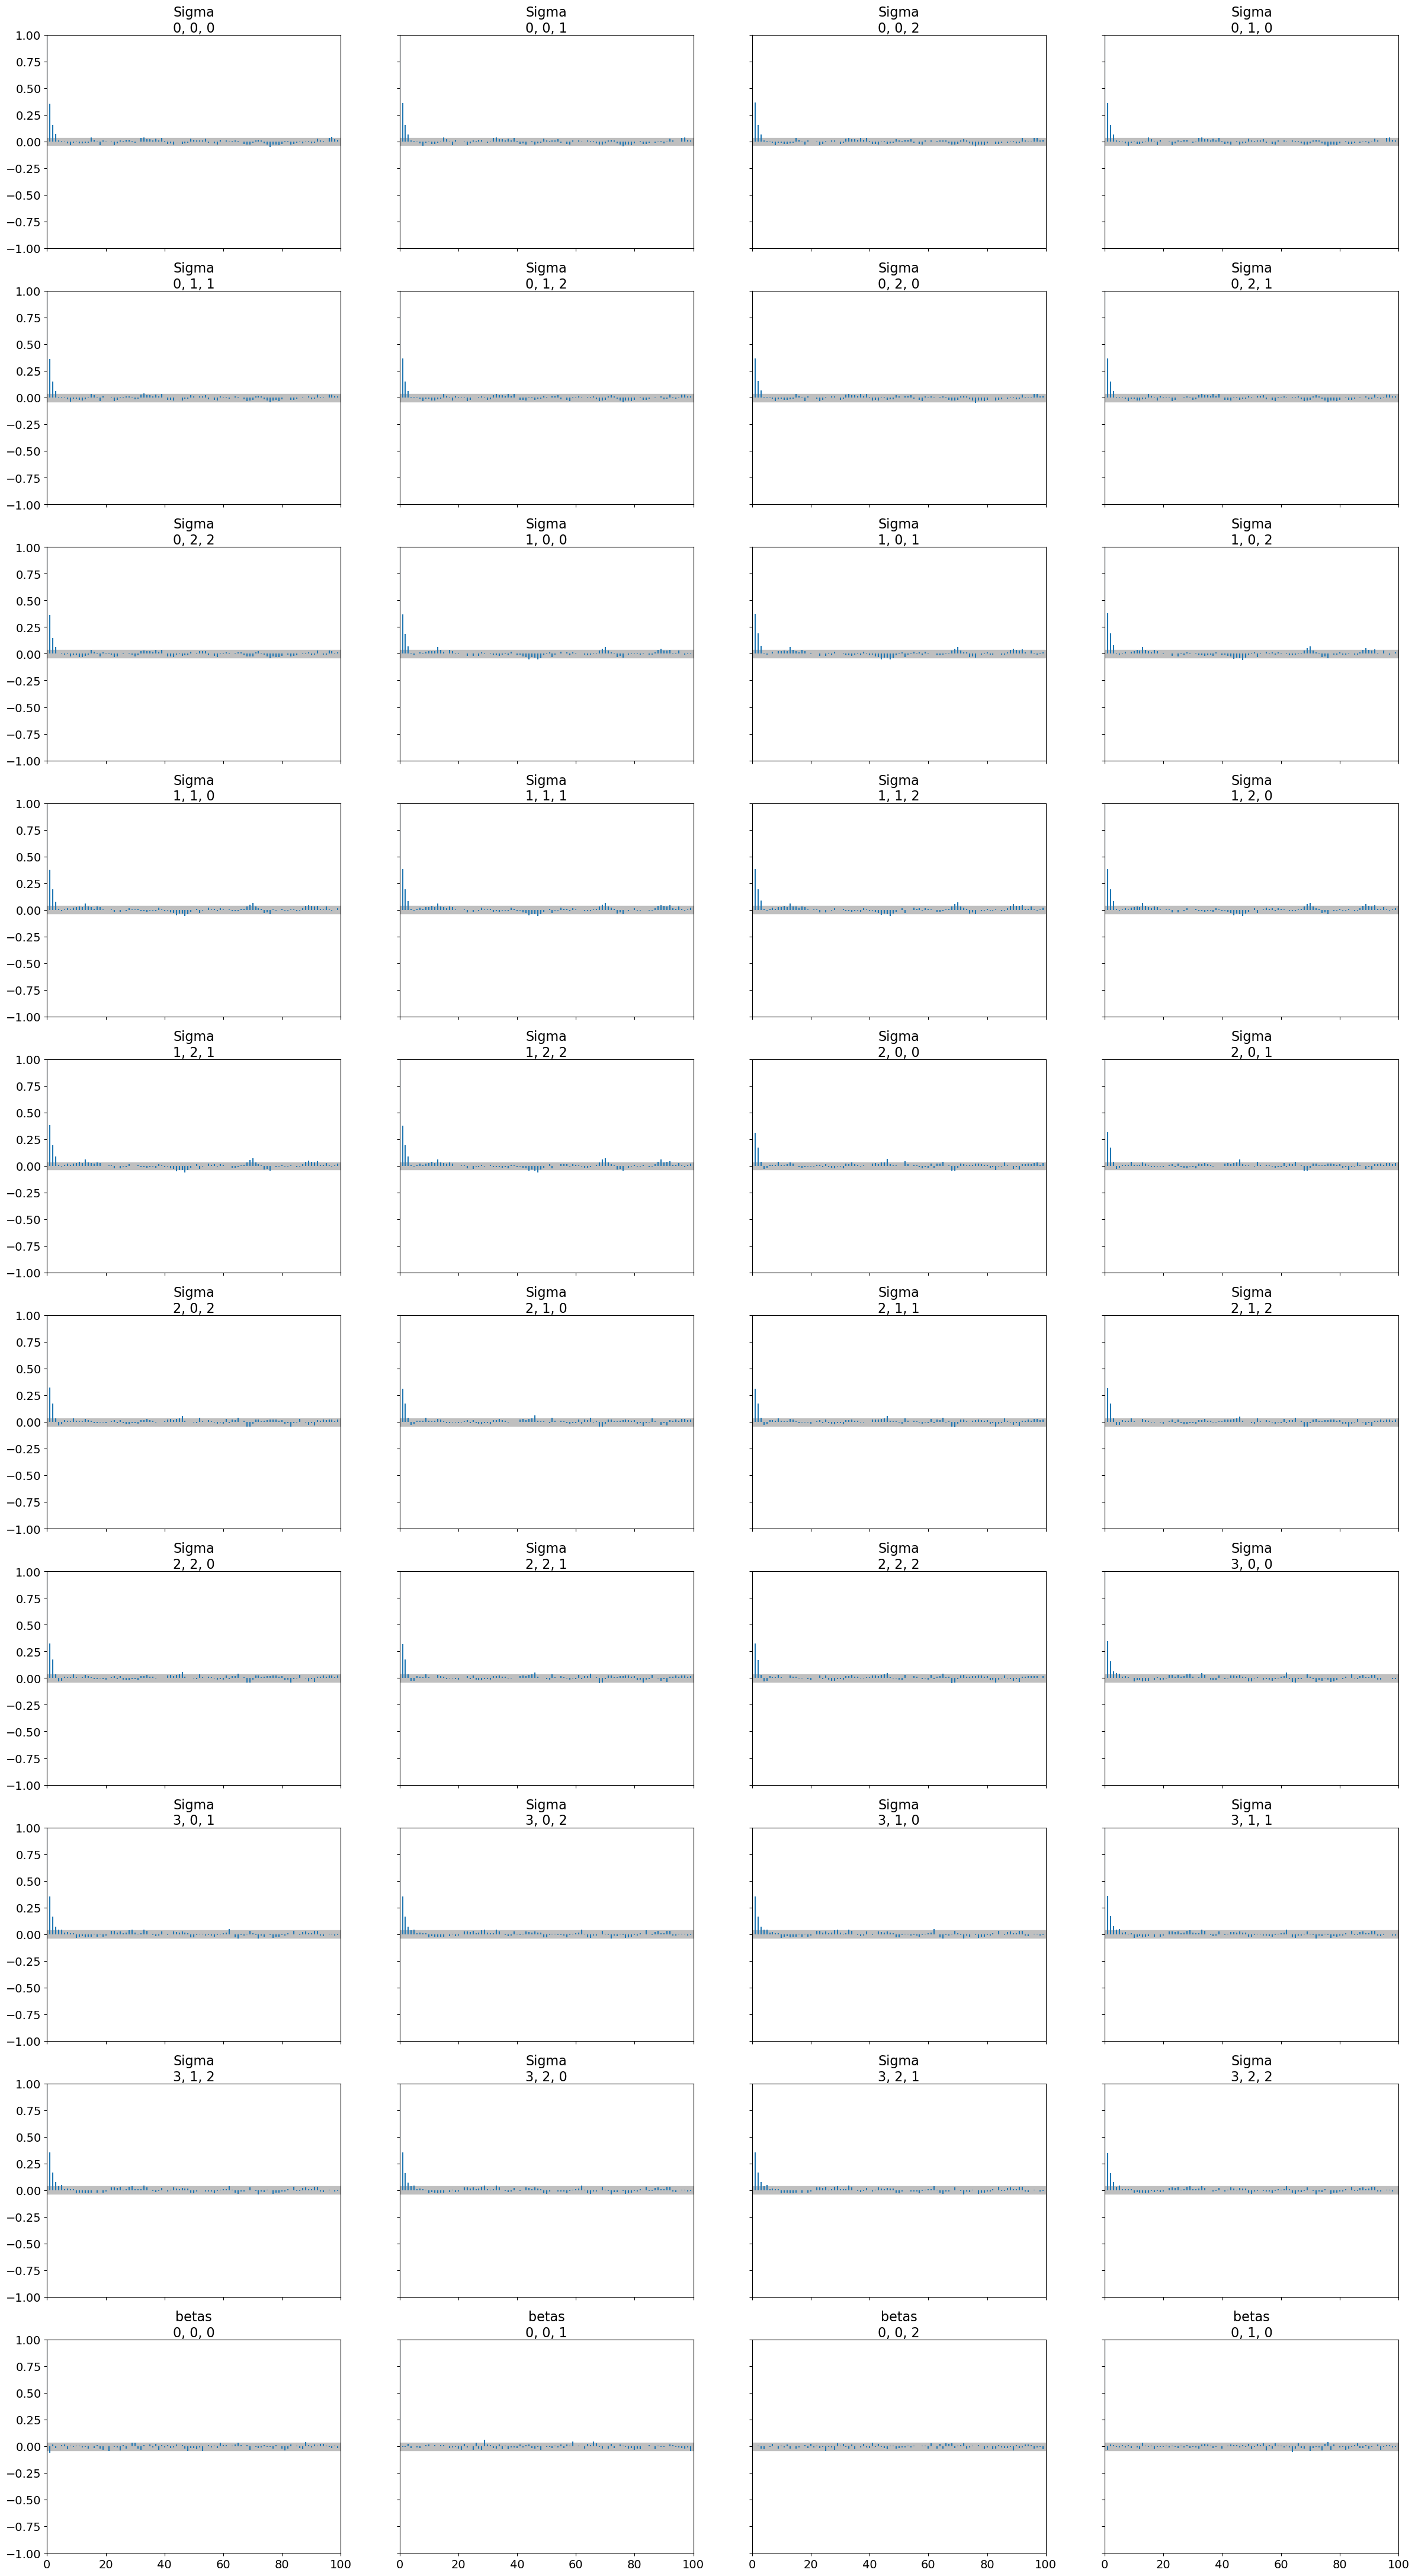

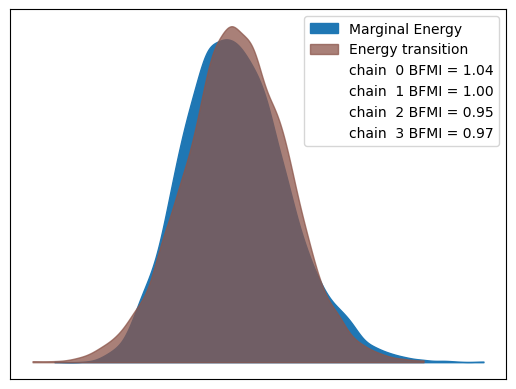

In [18]:
az.plot_trace(trace)
plt.tight_layout()
plt.show()

az.plot_autocorr(trace)
plt.show()

az.plot_energy(trace)
plt.show()

#### Inference with Bayesian posterior analysis and MCMC diagnostics

* The r_hat statistic for all parameters is much less than 1.01 and very close to 1, indicating the chains are mixing well and converging on the same results.
* From the trace plots above, we see that the chains for each parameter are in agreement and have converged closely on the same result.
* From the energy plot above, we see that the marginal energy distribution and the transition energy distribution for the most part overlap, indicating our sampler is exploring the parameter space well. In addition, we see that the BFMI for each chain is very close to 1, indicating the sampler is exploring the posterior thoroughly, and that we can be confident in the estimates given by our analysis.
* In this example, we took a total of 12,000 draws for each parameter. Looking at the az.summary, all paramters have ess_bulk of at least 5,000, meaning we have taken the rough equivalent of at least 5,000 independent samples for each parameter. This amount of independent samples seems sufficient, as our other diagnostics explained in the previous points suggest the chains have converged and have mixed well. In addition, the autocorrelation plots above show a near-zero autocorrelation after the first few lags, meaning that each sample in the chain becomes independent of all previous samples after a few more draws.

Overall, our analysis shows that the algorithm provided reliable estimates of the relationships between site, sex, age, and the outcomes 'hdlngth' (head length), 'totlngth' (total length), and 'taill' (tail length) using Bayesian multivariate regression.

### Question 3

For this question, I will be using the Titanic-Dataset.csv dataset from: https://www.kaggle.com/datasets/yasserh/titanic-dataset.

In [40]:
df = pd.read_csv('Titanic-Dataset.csv')
df = df.dropna(subset=['Sex', 'Age', 'Parch', 'Fare', 'Survived', 'Pclass'])
df

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...,...
885,886,0,3,"Rice, Mrs. William (Margaret Norton)",female,39.0,0,5,382652,29.1250,NaN,Q
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C


I will try to predict 'Survived' and 'Pclass' (p=2) using 'Sex', 'Age', 'Parch', and 'Fare' (m=4). I will modify Pclass to be a binary variable, equal to 0 if Pclass (ticket class) is 2 or 3, and equal to 1 if Pclass is 1.

To downsample the dataset, I will only use 150 observations but keep the number of predictors and outcomes the same.

In [ ]:
import pandas as pd
import numpy as np
import pymc as pm
import arviz as az
import matplotlib.pyplot as plt

df['Sex'] = df['Sex'].map({'male': 0, 'female': 1})

predictor_cols = ['Sex', 'Age', 'Parch', 'Fare']
df[predictor_cols] = df[predictor_cols].apply(pd.to_numeric, errors='coerce')

df['Pclass_bin'] = df['Pclass'].apply(lambda x: 1 if x == 1 else 0)

outcome_cols = ['Survived', 'Pclass_bin']
df[outcome_cols] = df[outcome_cols].apply(pd.to_numeric, errors='coerce')

df = df.dropna(subset=['Sex', 'Age', 'Parch', 'Fare', 'Survived', 'Pclass_bin'])

# sample 150 observations for analysis
df = df.sample(n=150, random_state=42)

# outcome and predictor matrices
Y = df[outcome_cols].values.astype(np.float64)  # shape (n, m), where m=2
X = df[predictor_cols].values.astype(np.float64)  # shape (n, p), where p=4

n, p = X.shape  # n = number of observations, p = number of predictors
m = Y.shape[1]  # m = number of outcomes


with pm.Model() as multivariate_classification_model:

    betas = pm.Normal('betas', mu=0, sigma=1, shape=(p, m))
    
    packed_L = pm.LKJCholeskyCov(
        "packed_L", n=m, eta=2.0,
        sd_dist=pm.Exponential.dist(1.0, shape=m),
        compute_corr=False
    )
    L = pm.expand_packed_triangular(m, packed_L)
    
    z = pm.MvNormal('z', mu=pm.math.dot(X, betas), chol=L, shape=(n, m))
    
    y_obs = pm.Bernoulli('y_obs', p=pm.math.invprobit(z), observed=Y)
    
    start = {
        "betas": np.zeros((p, m)),
        "packed_L": np.ones((int(m * (m + 1) / 2),)),
        "z": np.zeros((n, m))
    }
    
    trace = pm.sample(
        draws=3000,
        tune=1000,
        target_accept=0.975,
        random_seed=365,
        init="jitter+adapt_diag",
        start=start
    )

In [ ]:
az.summary(trace, round_to=5)

In [ ]:
az.plot_trace(trace)
plt.tight_layout()
plt.show()

az.plot_autocorr(trace)
plt.show()

az.plot_energy(trace)
plt.show()

#### Inference with Bayesian posterior analysis and MCMC diagnostics

* The r_hat statistic for all parameters is much less than 1.01 and very close to 1, indicating the chains are mixing well and converging on the same results.
* From the trace plots above, we see that the chains for each parameter are in agreement and have converged closely on the same result.
* From the energy plot above, we see that the marginal energy distribution and the transition energy distribution for the most part overlap, indicating our sampler is exploring the parameter space well. In addition, we see that the BFMI for each chain is very close to 1, indicating the sampler is exploring the posterior thoroughly, and that we can be confident in the estimates given by our analysis.

Overall, our analysis shows that the algorithm provided reliable estimates of the relationships between 'Sex', 'Age', 'Parch', 'Fare' and the outcomes 'Survived', 'Pclass_bin' using Bayesian multivariate classification.